## 1. Importacion de paquetes

In [23]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Definicion del sistema de Lorenz

In [24]:
def lorenz(x, y, z, sigma=10, rho=28, beta=8/3):
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return dx, dy, dz

## 3. Metodo de Euler

In [25]:
def euler_lorenz(x0, y0, z0, h, steps, sigma, rho, beta):
    x, y, z = [x0], [y0], [z0]
    for _ in range(steps):
        dx, dy, dz = lorenz(x[-1], y[-1], z[-1], sigma, rho, beta)
        x.append(x[-1] + h * dx)
        y.append(y[-1] + h * dy)
        z.append(z[-1] + h * dz)
    return np.array(x), np.array(y), np.array(z)

## 4. Metodo de Runge-Kutta de 4º orden (RK4)

In [26]:
def rk4_lorenz(x0, y0, z0, h, steps, sigma, rho, beta):
    x, y, z = [x0], [y0], [z0]
    for _ in range(steps):
        x_n, y_n, z_n = x[-1], y[-1], z[-1]

        dx1, dy1, dz1 = lorenz(x_n, y_n, z_n, sigma, rho, beta)
        dx2, dy2, dz2 = lorenz(x_n + h*dx1/2, y_n + h*dy1/2, z_n + h*dz1/2, sigma, rho, beta)
        dx3, dy3, dz3 = lorenz(x_n + h*dx2/2, y_n + h*dy2/2, z_n + h*dz2/2, sigma, rho, beta)
        dx4, dy4, dz4 = lorenz(x_n + h*dx3, y_n + h*dy3, z_n + h*dz3, sigma, rho, beta)

        x.append(x_n + (h/6)*(dx1 + 2*dx2 + 2*dx3 + dx4))
        y.append(y_n + (h/6)*(dy1 + 2*dy2 + 2*dy3 + dy4))
        z.append(z_n + (h/6)*(dz1 + 2*dz2 + 2*dz3 + dz4))
    return np.array(x), np.array(y), np.array(z)

## 5. Parametros y condiciones iniciales

In [27]:
sigma, rho, beta = 10, 28, 8/3
x0, y0, z0 = 1.0, 1.0, 1.0
h = 0.01
steps = 10000

## 6. Ejecucion de la simulacion

In [28]:
x_euler, y_euler, z_euler = euler_lorenz(x0, y0, z0, h, steps, sigma, rho, beta)
x_rk4, y_rk4, z_rk4 = rk4_lorenz(x0, y0, z0, h, steps, sigma, rho, beta)

## 7. Grafica de resultados 3D

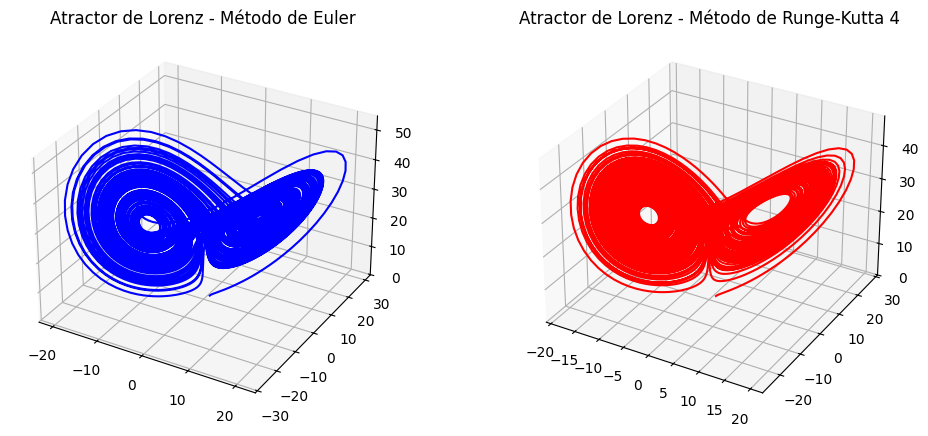

In [29]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(x_euler, y_euler, z_euler, color='blue')
ax1.set_title('Atractor de Lorenz - Método de Euler')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(x_rk4, y_rk4, z_rk4, color='red')
ax2.set_title('Atractor de Lorenz - Método de Runge-Kutta 4')

plt.show()